#### 10th August 2026
## MLL LAB WEEK 3

#### Anirvin Iyer <br>240905318 <br>CSE D - 32

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [26]:

df_iris= pd.read_csv('iris.csv')
df_study=pd.read_csv('study.csv')

### 1. Consider the hepatitis/ pima-indians-diabetes csv file, perform the following date pre-processing.
##### 1. Load data in Pandas.<br>2. Drop columns that aren’t useful.<br>3. Drop rows with missing values.<br>4. Create dummy variables.<br>5. Take care of missing data.<br>6. Convert the data frame to NumPy.<br>7. Divide the data set into training data and test data.

In [68]:
#1
df_hep= pd.read_csv('hepatitis_csv.csv')
df_hep = df_hep.drop(columns=['Unnamed: 0'], errors='ignore')
df_hep_nona=df_hep.dropna()


In [69]:
df_hep_nona= pd.get_dummies(df_hep, columns=['sex'], drop_first=True)

In [70]:
df_hep_nona= pd.get_dummies(df_hep, columns=['class'], drop_first=True)

In [72]:
df_hep_nona.isnull().sum().sum()

167

In [75]:
X = df_hep_nona.drop(columns=['class_live'])
y = df_hep_nona['class_live']

X = X.to_numpy()
y = y.to_numpy()

In [79]:
np.random.seed(42)

indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (124, 19)
X_test: (31, 19)
y_train: (124,)
y_test: (31,)


### 2. a. Construct a CSV file with the following attributes:
##### Study time in hours of ML lab course (x)<br>Score out of 10 (y)<br>The dataset should contain 10 rows.
### b. Create a regression model and display the following:
##### Coefficients: B0 (intercept) and B1 (slope)<br>RMSE (Root Mean Square Error)<br>Predicted responses
### c. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.
### d. Implement the model using two methods:
##### Pedhazur formula (intuitive)<br>Calculus method (partial derivatives, refer to class notes)
### e. Compare the coefficients obtained using both methods and compare them with the analytical solution.
### f. Test your model to predict the score obtained when the study time of a student is 10 hours.


In [81]:
df_study

,Study_Time_Hours,Score
0,1,2
1,2,3
2,3,4
3,4,5
4,5,5
5,6,6
6,7,7
7,8,8
8,9,9
9,10,10



--- PEDHAZUR METHOD ---
B0 (Intercept) = 1.200000000000001
B1 (Slope)     = 0.8545454545454545
RMSE           = 0.2558408596267326

Predicted responses:
[2.05454545 2.90909091 3.76363636 4.61818182 5.47272727 6.32727273
 7.18181818 8.03636364 8.89090909 9.74545455]

--- CALCULUS METHOD ---
B0 (Intercept) = 1.1999999999999986
B1 (Slope)     = 0.8545454545454547
RMSE           = 0.25584085962673253

Predicted responses:
[2.05454545 2.90909091 3.76363636 4.61818182 5.47272727 6.32727273
 7.18181818 8.03636364 8.89090909 9.74545455]

--- ANALYTICAL SOLUTION ---
B0 (Intercept) = 1.200000000000001
B1 (Slope)     = 0.8545454545454547
RMSE           = 0.25584085962673253


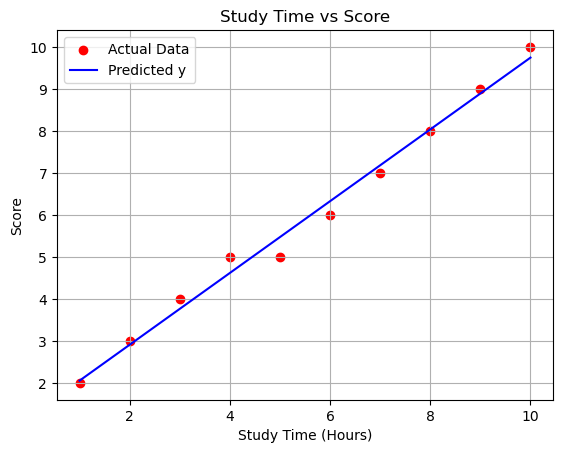


--- COMPARISON ---
B0:
Pedhazur   : 1.200000000000001
Calculus   : 1.1999999999999986
Analytical : 1.200000000000001

B1:
Pedhazur   : 0.8545454545454545
Calculus   : 0.8545454545454547
Analytical : 0.8545454545454547

--- PREDICTION ---
Study time = 10 hours
Predicted score = 9.745454545454548


In [85]:

x = df_study['Study_Time_Hours'].to_numpy(dtype=float)
y = df_study['Score'].to_numpy(dtype=float)

n = len(x)


# ============================================================
# 2(d) METHOD 1: PEDHAZUR FORMULA
# ============================================================

x_mean = np.mean(x)
y_mean = np.mean(y)

B1_ped = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

B0_ped = y_mean - B1_ped * x_mean

y_pred_ped = B0_ped + B1_ped * x

rmse_ped = np.sqrt(np.mean((y - y_pred_ped) ** 2))


# ============================================================
# 2(d) METHOD 2: CALCULUS METHOD
# ============================================================
# Model:
# y_hat = B0 + B1*x
#
# SSE = sum((y - B0 - B1*x)^2)
#
# Taking partial derivatives:
#
# d(SSE)/dB0 = 0
# d(SSE)/dB1 = 0
#
# Gives the normal equations:
#
# n*B0 + B1*sum(x)   = sum(y)
# B0*sum(x) + B1*sum(x^2) = sum(x*y)


A = np.array([
    [n, np.sum(x)],
    [np.sum(x), np.sum(x ** 2)]
])

C = np.array([
    np.sum(y),
    np.sum(x * y)
])

B0_cal, B1_cal = np.linalg.solve(A, C)

y_pred_cal = B0_cal + B1_cal * x

rmse_cal = np.sqrt(np.mean((y - y_pred_cal) ** 2))


# ============================================================
# ANALYTICAL SOLUTION
# ============================================================

# Using the same normal equations in matrix form:
# B = (X^T X)^(-1) X^T y

X = np.column_stack((np.ones(n), x))

B = np.linalg.inv(X.T @ X) @ X.T @ y

B0_analytical = B[0]
B1_analytical = B[1]

y_pred_analytical = B0_analytical + B1_analytical * x

rmse_analytical = np.sqrt(
    np.mean((y - y_pred_analytical) ** 2)
)


# ============================================================
# 2(b) DISPLAY COEFFICIENTS, RMSE AND PREDICTED RESPONSES
# ============================================================

print("\n--- PEDHAZUR METHOD ---")
print("B0 (Intercept) =", B0_ped)
print("B1 (Slope)     =", B1_ped)
print("RMSE           =", rmse_ped)

print("\nPredicted responses:")
print(y_pred_ped)


print("\n--- CALCULUS METHOD ---")
print("B0 (Intercept) =", B0_cal)
print("B1 (Slope)     =", B1_cal)
print("RMSE           =", rmse_cal)

print("\nPredicted responses:")
print(y_pred_cal)


print("\n--- ANALYTICAL SOLUTION ---")
print("B0 (Intercept) =", B0_analytical)
print("B1 (Slope)     =", B1_analytical)
print("RMSE           =", rmse_analytical)


# ============================================================
# 2(c) SCATTER PLOT AND REGRESSION LINE
# ============================================================

plt.scatter(x, y, color='red', label='Actual Data')

plt.plot(
    x,
    y_pred_ped,
    color='blue',
    label='Predicted y'
)

plt.xlabel('Study Time (Hours)')
plt.ylabel('Score')
plt.title('Study Time vs Score')
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 2(e) COMPARE THE COEFFICIENTS
# ============================================================

print("\n--- COMPARISON ---")

print("B0:")
print("Pedhazur   :", B0_ped)
print("Calculus   :", B0_cal)
print("Analytical :", B0_analytical)

print("\nB1:")
print("Pedhazur   :", B1_ped)
print("Calculus   :", B1_cal)
print("Analytical :", B1_analytical)


# ============================================================
# 2(f) PREDICT SCORE FOR 10 HOURS
# ============================================================

study_time = 10

predicted_score = B0_analytical + B1_analytical * study_time

print("\n--- PREDICTION ---")
print("Study time =", study_time, "hours")
print("Predicted score =", predicted_score)